In [1]:
# =========================
# 1. Import Library
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Agar grafik lebih enak dilihat
plt.style.use('ggplot')

In [2]:
# =========================
# 2. Load & Siapkan Data
# =========================
df = pd.read_csv('GDP.csv')

# Deteksi nama kolom negara
if 'Country Name' in df.columns:
    country_col = 'Country Name'
elif 'Country' in df.columns:
    country_col = 'Country'
else:
    raise ValueError("Kolom nama negara tidak ditemukan. Cek nama kolom di GDP.csv")

# Pilih negara (sesuaikan dengan kebutuhanmu)
target_country = 'Indonesia'   # bisa kamu ganti

row_country = df[df[country_col] == target_country].iloc[0]

# Ambil hanya kolom tahun (yang bisa di-cast ke int)
year_cols = []
for col in df.columns:
    try:
        int(col)  # kalau kolom bisa di-cast ke int, berarti ini tahun
        year_cols.append(col)
    except:
        continue

years = np.array([int(y) for y in year_cols])
gdp_values = row_country[year_cols].values.astype(float)

# Buang nilai NaN (kalau ada tahun yang kosong)
mask_valid = ~np.isnan(gdp_values)
years = years[mask_valid]
gdp_values = gdp_values[mask_valid]

print("Negara:", target_country)
print("Tahun awal-akhir:", years[0], "–", years[-1])
print("Jumlah data:", len(years))

Negara: Indonesia
Tahun awal-akhir: 1967 – 2022
Jumlah data: 56


In [3]:
# =========================
# 3. Ubah ke Bentuk Time Index t = 0,1,2,...
# =========================
# Karena datanya tahunan, kita bisa pakai t langkah 1 tahun
t_data = np.arange(len(gdp_values))   # 0,1,2,...,N-1

In [4]:
# =========================
# 4. Estimasi Parameter r dan K
#    r: laju pertumbuhan
#    K: kapasitas jangka panjang (steady-state GDP)
# =========================
# Estimasi r dari pendekatan eksponensial:
# Model kasar: Y(t) ~ Y0 * exp(r t)  -> ln(Y) ~ ln(Y0) + r t
logY = np.log(gdp_values)
r_est, b_est = np.polyfit(t_data, logY, 1)

# Estimasi awal K secara kasar: misalnya 1.5 × GDP maksimum
K_est = 1.5 * np.max(gdp_values)

print(f"Estimasi r (laju pertumbuhan tahunan) ≈ {r_est:.4f} per tahun")
print(f"Estimasi K (kapasitas jangka panjang) ≈ {K_est:,.2f}")

Estimasi r (laju pertumbuhan tahunan) ≈ 0.0891 per tahun
Estimasi K (kapasitas jangka panjang) ≈ 1,978,650,330,583.50


In [5]:

# =========================
# 5. Definisi Model ODE (Solow Sederhana) & Metode Euler
# =========================
def model_gdp_solow(Y, t, r, K):
    """
    Model Pertumbuhan Solow (sederhana / logistik satu variabel):
    dY/dt = r * Y * (1 - Y/K)
    """
    return r * Y * (1.0 - Y / K)

def euler_method(func, y0, t_points, params):
    """
    Menerapkan Metode Euler secara manual.
    func     : fungsi turunan f(t, y)
    y0       : nilai awal y(t0)
    t_points : array waktu (mis. 0,1,2,...)
    params   : tuple parameter tambahan untuk func (mis. (r, K))
    """
    y = np.zeros(len(t_points))
    y[0] = y0
    h = t_points[1] - t_points[0]    # step size

    for i in range(len(t_points) - 1):
        slope = func(y[i], t_points[i], *params)  # f(t_i, y_i)
        y[i+1] = y[i] + h * slope                 # y_{i+1} = y_i + h*f(...)

    return y


In [6]:
# =========================
# 6. Simulasi Euler dengan step size h = 1 tahun
# =========================
t_start = 0
t_end = len(gdp_values) - 1
h = 1.0

t_points = np.arange(t_start, t_end + h, h)  # 0,1,...,N-1

Y0 = gdp_values[0]        # nilai awal GDP dari data
r = r_est                 # boleh kamu ubah manual untuk eksperimen
K = K_est                 # boleh kamu ubah manual juga

Y_euler = euler_method(model_gdp_solow, Y0, t_points, (r, K))


In [7]:
# =========================
# 7. Hitung MSE antara Data Asli dan Simulasi
# =========================
mse = np.mean((gdp_values - Y_euler)**2)
print(f"Mean Squared Error (MSE) antara data dan Euler-Solow: {mse:,.2f}")

Mean Squared Error (MSE) antara data dan Euler-Solow: 114,413,186,482,037,470,527,488.00


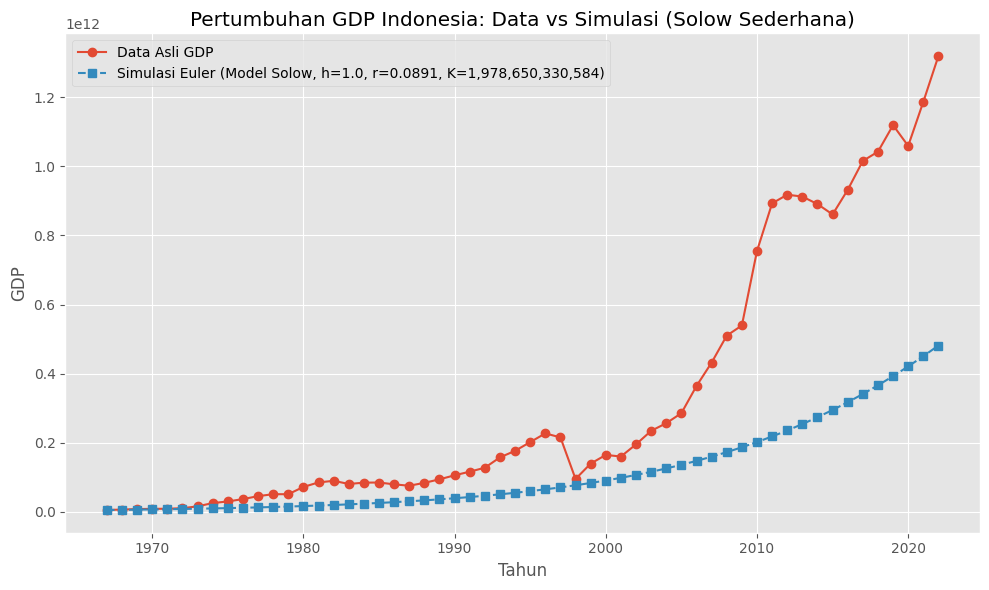

In [8]:
#=========================
# 8. Visualisasi Hasil
# =========================
plt.figure(figsize=(10, 6))
plt.plot(years, gdp_values, 'o-', label='Data Asli GDP')
plt.plot(years, Y_euler, 's--',
         label=f'Simulasi Euler (Model Solow, h={h}, r={r:.4f}, K={K:,.0f})')
plt.xlabel('Tahun')
plt.ylabel('GDP')
plt.title(f'Pertumbuhan GDP {target_country}: Data vs Simulasi (Solow Sederhana)')
plt.legend()
plt.tight_layout()
plt.show()

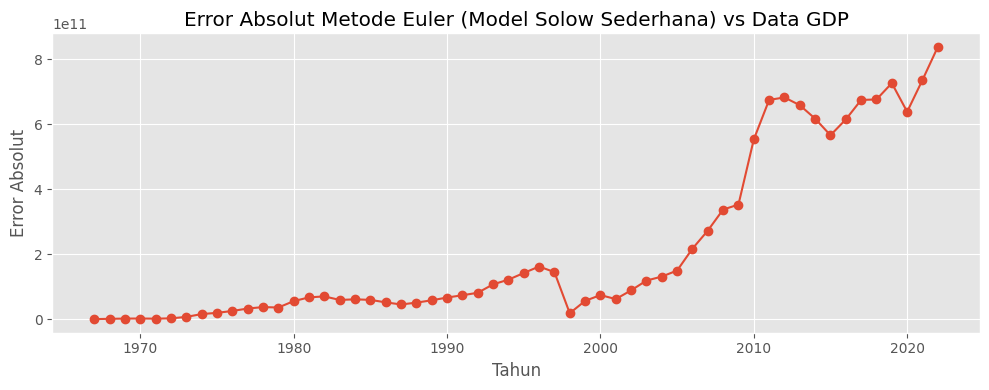

In [9]:
# =========================
# 9. Grafik Error per Tahun
# =========================
error = gdp_values - Y_euler
abs_error = np.abs(error)

plt.figure(figsize=(10, 4))
plt.plot(years, abs_error, 'o-')
plt.xlabel('Tahun')
plt.ylabel('Error Absolut')
plt.title('Error Absolut Metode Euler (Model Solow Sederhana) vs Data GDP')
plt.tight_layout()
plt.show()